In [5]:
# 1
!pip install category_encoders

In [6]:
# 2
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
def plot(pred):
  df = pd.read_csv("/content/drive/MyDrive/ML_Project/train_data.csv")
  pred = pd.DataFrame(pred)
  df = df[['displayId','clicked']]
  a = df.join(pred).rename(columns={0:'pred'}, inplace=False).groupby('displayId').mean()
  b = a.sort_values(by =['clicked'])
  b['ind'] = range(len(b))
  b.plot(x='ind', y=['pred'])
  b.plot(x='ind', y=['clicked'])


In [3]:
def reliability_diagram(probs):
  from sklearn.calibration import calibration_curve
  from matplotlib import pyplot
  import matplotlib.pyplot as plt

  df = pd.read_csv("/content/drive/MyDrive/ML_Project/train_data.csv")
  y = df['clicked']
  fop, mpv = calibration_curve(y, probs, n_bins=10, normalize=True)
  # plot perfectly calibrated
  plt.figure()
  pyplot.plot([0, 1], [0, 1], linestyle='--')
  # plot calibrated reliability
  pyplot.plot(mpv, fop, marker='.')
  pyplot.show()

In [4]:
def score(actual, predicted, prob):
  from sklearn.metrics import classification_report,confusion_matrix
  from sklearn.metrics import roc_auc_score
  from sklearn.metrics import log_loss
  print('CONFUSION MATRIX')
  print(confusion_matrix(actual, predicted, normalize='all'))
  print(classification_report(actual, predicted))
  print("AUC:")
  print(roc_auc_score(actual, predicted))
  print("CROSS-ENTROPY:")
  print(log_loss(actual, prob))

In [7]:
# 3
project_dir = '/content/drive/MyDrive/ML_Project/'
train = pd.read_csv("/content/drive/MyDrive/ML_Project/train_data.csv")
print(train.head())
print(len(train))
train = train.dropna()
print(len(train))
test = pd.read_csv("/content/drive/MyDrive/ML_Project/test_data.csv")
print(test.head())
print(len(test))
test = test.dropna()
print(len(test))

   displayId      timestamp  dayOfWeek  hourOfDay  advertiserId  campaignId  creativeId  publisher  widgetId  device  os  browser  source    docId   userId  clicked
0    4706262  1578429005696          4          0           290        7855           6         10      6262       0   0        0      11  3543873  2688642        1
1    4706262  1578429005696          4          0          1386        7967          15         10      6262       0   0        0      11  3543873  2688642        0
2    4706262  1578429005696          4          0           378        1160        3610         10      6262       0   0        0      11  3543873  2688642        0
3    4706267  1578429007726          4          0          6642         804        3475         14       607       1   3        0      15  6245475  2688641        1
4    4706267  1578429007726          4          0          8414        6155        5271         14       607       1   3        0      15  6245475  2688641        0
3768416
37

In [8]:
# 4
y_train = train['clicked']
train = train.drop('clicked', 1)

'\nfrom collections import Counter, defaultdict\nfor col in test.columns:\n    l1 = Counter(list(train[col]))\n    l2 = Counter(list(test[col]))\n    print(col)\n    ours = 0\n    all = 0\n    ours_weighted = 0\n    all_weighted = 0\n    ours3 = 0\n    all3 = 0\n    for k2, v2 in l2.items():\n        ours += 1 if k2 in l1.keys() else 0\n        ours_weighted += v2 if k2 in l1.keys() else 0\n        all += 1\n        all_weighted += v2\n        ours3 += l1[k2] if k2 in l1.keys() else 0\n        all3 += l1[k2]\n\n    print(ours / all)\n    print(ours_weighted / all_weighted)\n    print((ours3) / (all3 + 0.0001))\n    print()\n'

In [7]:
# 5
import math
print(train.describe())
print({a:str(len(train[a].unique())) for a in train.columns})
print(sum([math.log2(len(train[a].unique())) for a in train.columns if not a in ['timestamp', 'displayId', 'source', 'device']]))
print(len(train))

one_hots = ['dayOfWeek', 'hourOfDay', 'device', 'os', 'browser']
big_uniques = ['displayId', 'timestamp', 'docId', 'userId']
middle = list({'advertiserId': '200', 'campaignId': '474', 'creativeId': '2696', 
          'publisher': '759', 'widgetId': '1165', 'source': '2868'}.keys())
print([type(train[a][0]) for a in train.columns])

          displayId     timestamp     dayOfWeek     hourOfDay  advertiserId    campaignId    creativeId     publisher      widgetId        device            os       browser        source         docId        userId
count  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06
mean   3.044210e+06  1.579005e+12  2.822654e+00  1.128271e+01  4.851426e+03  4.556158e+03  3.923456e+03  2.463082e+02  7.500866e+03  3.409207e-01  4.306032e-01  1.209916e+00  1.848337e+03  5.065981e+06  1.501631e+06
std    1.019521e+06  3.571385e+08  1.914881e+00  5.618726e+00  2.899004e+03  2.647040e+03  2.482294e+03  5.164171e+02  4.301190e+03  4.817837e-01  6.516009e-01  2.629931e+00  6.529483e+03  3.424284e+06  7.132266e+05
min    1.115095e+06  1.578429e+12  0.000000e+00  0.000000e+00  1.000000e+00  3.000000e+01  6.000000e+00  0.000000e+00  9.000000e+00  0.0

In [9]:
# 7
from sklearn.preprocessing import LabelBinarizer, LabelEncoder
from category_encoders import *
from datetime import datetime

train = train.drop('source', 1)
train = train.drop('displayId', 1)
train = train.drop('device', 1)
train = train.drop('docId', 1)
train = train.drop('userId', 1)
train = train.drop('timestamp', 1)

test = test.drop('source', 1)
test = test.drop('displayId', 1)
test = test.drop('device', 1)
test = test.drop('docId', 1)
test = test.drop('userId', 1)
test = test.drop('timestamp', 1)

old_cols = train.columns
encoder= BinaryEncoder(cols=train.columns,return_df=True)
train = encoder.fit_transform(train)
test = encoder.fit_transform(test)


# remove zeroes:
for col in old_cols:
    train = train.drop(str(col) + "_0", 1)
    test = test.drop(str(col) + "_0", 1)

for col in train.columns:
    if not col in test.columns:
        test[col] = 0

print(train.shape)
print(train.head(10))

print(test.shape)
print(test.head(10))

/usr/local/lib/python3.6/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm
/usr/local/lib/python3.6/dist-packages/category_encoders/utils.py:21: FutureWarning: is_categorical is deprecated and will be removed in a future version.  Use is_categorical_dtype instead
  elif pd.api.types.is_categorical(cols):
/usr/local/lib/python3.6/dist-packages/category_encoders/utils.py:21: FutureWarning: is_categorical is deprecated and will be removed in a future version.  Use is_categorical_dtype instead
  elif pd.api.types.is_categorical(cols):


(3768416, 68)
   dayOfWeek_1  dayOfWeek_2  dayOfWeek_3  hourOfDay_1  hourOfDay_2  hourOfDay_3  hourOfDay_4  hourOfDay_5  advertiserId_1  advertiserId_2  advertiserId_3  advertiserId_4  advertiserId_5  advertiserId_6  advertiserId_7  advertiserId_8  campaignId_1  campaignId_2  campaignId_3  campaignId_4  campaignId_5  campaignId_6  campaignId_7  campaignId_8  campaignId_9  creativeId_1  creativeId_2  creativeId_3  creativeId_4  creativeId_5  creativeId_6  creativeId_7  creativeId_8  creativeId_9  creativeId_10  creativeId_11  creativeId_12  publisher_1  publisher_2  publisher_3  publisher_4  publisher_5  publisher_6  publisher_7  publisher_8  publisher_9  publisher_10  widgetId_1  widgetId_2  widgetId_3  widgetId_4  widgetId_5  widgetId_6  widgetId_7  widgetId_8  widgetId_9  widgetId_10  widgetId_11  os_1  os_2  os_3  browser_1  browser_2  browser_3  browser_4  browser_5  browser_6  browser_7
0            0            0            1            0            0            0            0   

In [10]:
# 8
train = train.reindex(sorted(train.columns), axis=1)
test = test.reindex(sorted(test.columns), axis=1)

print(train.head())
print(test.head())

   advertiserId_1  advertiserId_2  advertiserId_3  advertiserId_4  advertiserId_5  advertiserId_6  advertiserId_7  advertiserId_8  browser_1  browser_2  browser_3  browser_4  browser_5  browser_6  browser_7  campaignId_1  campaignId_2  campaignId_3  campaignId_4  campaignId_5  campaignId_6  campaignId_7  campaignId_8  campaignId_9  creativeId_1  creativeId_10  creativeId_11  creativeId_12  creativeId_2  creativeId_3  creativeId_4  creativeId_5  creativeId_6  creativeId_7  creativeId_8  creativeId_9  dayOfWeek_1  dayOfWeek_2  dayOfWeek_3  hourOfDay_1  hourOfDay_2  hourOfDay_3  hourOfDay_4  hourOfDay_5  os_1  os_2  os_3  publisher_1  publisher_10  publisher_2  publisher_3  publisher_4  publisher_5  publisher_6  publisher_7  publisher_8  publisher_9  widgetId_1  widgetId_10  widgetId_11  widgetId_2  widgetId_3  widgetId_4  widgetId_5  widgetId_6  widgetId_7  widgetId_8  widgetId_9
0               0               0               0               0               0               0            

In [11]:
# 11
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2


fs = SelectKBest(score_func=chi2, k=30)
fs.fit(train, y_train)
train = pd.DataFrame(fs.transform(train))
test = pd.DataFrame(fs.transform(test))

print(train.shape)
print(test.shape)

(3768416, 30)
(1072876, 30)


In [13]:
#randomly removing false data to equlize the ratio of true and false
import numpy as np

false_index = y_train[y_train == 0].index
false_len = len(y_train[y_train == 0])
true_len = len(y_train) - false_len
f2t_rate = int(false_len / true_len)
remove_n = (f2t_rate-1)*true_len

drop_indices = np.random.choice(false_index, remove_n, replace=False)
y = y_train.drop(drop_indices)
X = train.drop(drop_indices).reset_index().drop('index', axis=1)

In [14]:
y = y.reset_index().drop('index', axis=1)
false_index = y[y == 0].index
true_index = y[y == 1].index
rate = 0.001
false_indices = np.random.choice(false_index, int(len(false_index)*rate), replace=False)
true_indeices = np.random.choice(true_index, int(len(true_index)*rate), replace=False)
undersampled_indices = np.append(true_indeices ,false_indices)
y = y.iloc[undersampled_indices, :]
X = X.iloc[undersampled_indices, :]

#MODELS




<div dir='rtl'>
<font size=5> 

همانطور که می‌دانیم، در دسته‌بند SVM یک صفحه جدا کننده داریم که به گونه‌ای قرار گرفته است که فاصله‌ی هر نزدیک ترین نقاط هر کلاس به آن با هم برابرند و این فاصله در میان تمامی فواصل موجود بیشینه است. در soft-margin SVM مدل خطا نیز می‌پذیرد و می‌توان با تغییر پارامتر C میزان حساسیت مدل به داده‌هایی که اشتباه دسته‌بندی شده‌اند را تنظیم کرد. هر چند که SVM در بسیاری از کاربرد‌ها مناسب عمل می‌کند اما در برخورد با داده‌های نامتوازن عملکرد خوبی ندارد. برای حل این مشکل از SVM وزن دار استفاده می‌کنیم به طوری که مدل نسبت به خطای دسته بندی کلاس اکثریت بسیار حساس است و برای کلاس اقلیت برعکس (C بزرگتر برای کلاس اقلیت). 
با توجه به اینکه حل مساله quadratic programming از سختی زمانی O(n^3) است ما تنها ۴۰۰۰ تا از ويزگی‌ها را انتخاب کردیم و روی آنها cross validation با ۱۰ fold اجرا کردیم تا زمان اجرای مدل کم شود. 
در نهایت مدل svm را با کرنل‌های متفاوت تست کردیم و نتیجه آنها در کد گزارش شده است.


</font>
</div>



##SVM

In [15]:
from numpy import mean
from sklearn.datasets import make_classification
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score
from sklearn.metrics import log_loss
import joblib

filename = project_dir + 'svc_linear.pkl'
model = SVC(gamma='scale',
            class_weight='balanced',
            kernel ='linear',
            probability=True)

kernel = ['linear', 'rbf', 'sigmoid']
param_grid = dict()

cv = RepeatedStratifiedKFold(n_splits=10,
                             n_repeats=1,
                             random_state=1)

svc = GridSearchCV(estimator=model,
                   param_grid=param_grid,
                   n_jobs=-1,
                   cv=cv,
                   scoring='roc_auc')

svc_result = svc.fit(X, y)
joblib.dump(svc, filename)

/usr/local/lib/python3.6/dist-packages/sklearn/utils/validation.py:760: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


['/content/drive/MyDrive/ML_Project/svc_linear.pkl']

CONFUSION MATRIX
[[0.51670808 0.25980783]
 [0.14969366 0.07379042]]
              precision    recall  f1-score   support

           0       0.78      0.67      0.72   2926235
           1       0.22      0.33      0.26    842181

    accuracy                           0.59   3768416
   macro avg       0.50      0.50      0.49   3768416
weighted avg       0.65      0.59      0.62   3768416

AUC:
0.49780026222251206
CROSS-ENTROPY:
0.5966399298747521


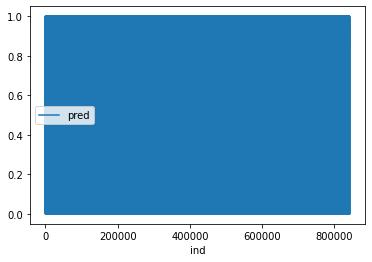

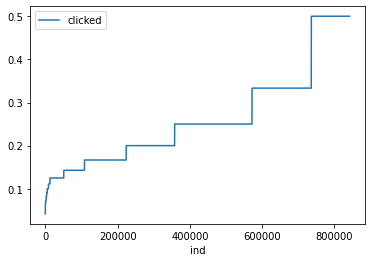

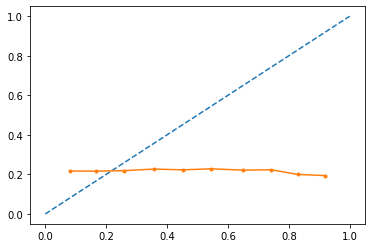

In [12]:
import joblib
filename = project_dir + 'svc_linear.pkl'

svc = joblib.load(filename)

prob_svc_train = svc.predict_proba(train)
predict_svc_train = svc.predict(train)
score(y_train, predict_svc_train, prob_svc_train)
plot(predict_svc_train)
reliability_diagram(prob_svc_train[:, 1])

In [ ]:
from numpy import mean
from sklearn.datasets import make_classification
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score
from sklearn.metrics import log_loss
import joblib

filename = project_dir + 'svc_poly.pkl'
model = SVC(gamma='scale',
            class_weight='balanced',
            kernel='poly',
            probability=True)

kernel = ['linear', 'rbf', 'sigmoid']
param_grid = dict()

cv = RepeatedStratifiedKFold(n_splits=10,
                             n_repeats=1,
                             random_state=1)

svc = GridSearchCV(estimator=model,
                   param_grid=param_grid,
                   n_jobs=-1,
                   cv=cv,
                   scoring='roc_auc')

svc_result = svc.fit(X, y)
joblib.dump(svc, filename)

CONFUSION MATRIX
[[0.41102973 0.36548619]
 [0.09929291 0.12419117]]
              precision    recall  f1-score   support

           0       0.81      0.53      0.64   2926235
           1       0.25      0.56      0.35    842181

    accuracy                           0.54   3768416
   macro avg       0.53      0.54      0.49   3768416
weighted avg       0.68      0.54      0.57   3768416

AUC:
0.5425151690570462
CROSS-ENTROPY:
0.6059294036731878


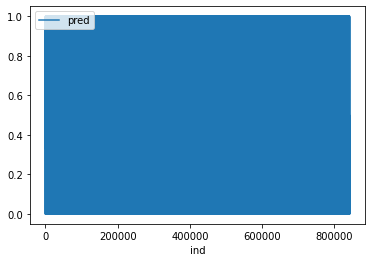

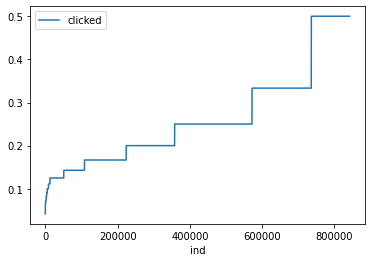

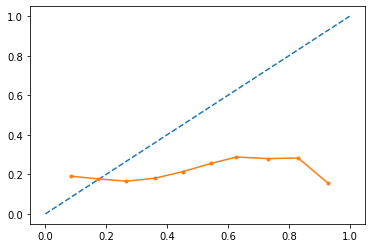

In [13]:
# load your model for further usage
import joblib
filename = project_dir + 'svc_poly.pkl'

svc = joblib.load(filename)

prob_svc_train = svc.predict_proba(train)
predict_svc_train = svc.predict(train)
score(y_train, predict_svc_train, prob_svc_train)
plot(predict_svc_train)
reliability_diagram(prob_svc_train[:, 1])

In [ ]:
from numpy import mean
from sklearn.datasets import make_classification
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score
from sklearn.metrics import log_loss
import joblib

filename = project_dir + 'svc_rbf.pkl'
model = SVC(gamma='scale',
            class_weight='balanced',
            kernel ='rbf',
            probability=True)

kernel = ['linear', 'rbf', 'sigmoid']
param_grid = dict()

cv = RepeatedStratifiedKFold(n_splits=10,
                             n_repeats=1,
                             random_state=1)

svc = GridSearchCV(estimator=model,
                   param_grid=param_grid,
                   n_jobs=-1,
                   cv=cv,
                   scoring='roc_auc')

svc_result = svc.fit(X, y)
joblib.dump(svc, filename)

/usr/local/lib/python3.6/dist-packages/sklearn/utils/validation.py:760: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


['/content/drive/MyDrive/ML_Project/svc_rbf.pkl']

CONFUSION MATRIX
[[0.43882098 0.33769494]
 [0.1050314  0.11845269]]
              precision    recall  f1-score   support

           0       0.81      0.57      0.66   2926235
           1       0.26      0.53      0.35    842181

    accuracy                           0.56   3768416
   macro avg       0.53      0.55      0.51   3768416
weighted avg       0.68      0.56      0.59   3768416

AUC:
0.5475713175509549
CROSS-ENTROPY:
0.6040043812236406


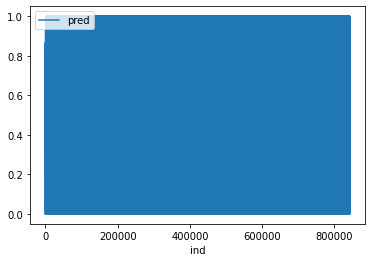

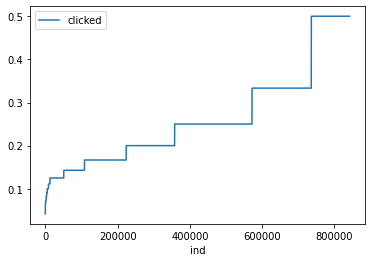

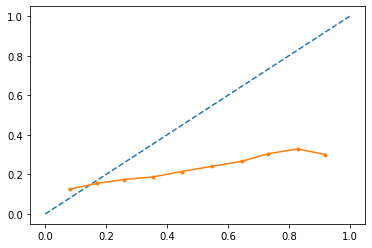

In [14]:
import joblib
filename = project_dir + 'svc_rbf.pkl'

svc = joblib.load(filename)

prob_svc_train = svc.predict_proba(train)
predict_svc_train = svc.predict(train)
score(y_train, predict_svc_train, prob_svc_train)
plot(predict_svc_train)
reliability_diagram(prob_svc_train[:, 1])

In [ ]:
from numpy import mean
from sklearn.datasets import make_classification
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score
from sklearn.metrics import log_loss
import joblib

filename = project_dir + 'svc_sigmoid.pkl'
model = SVC(gamma='scale',
            class_weight='balanced',
            kernel ='sigmoid',
            probability=True)

kernel = ['linear', 'rbf', 'sigmoid']
param_grid = dict()

cv = RepeatedStratifiedKFold(n_splits=10,
                             n_repeats=1,
                             random_state=1)

svc = GridSearchCV(estimator=model,
                   param_grid=param_grid,
                   n_jobs=-1,
                   cv=cv,
                   scoring='roc_auc')

svc_result = svc.fit(X, y)
joblib.dump(svc, filename)

/usr/local/lib/python3.6/dist-packages/sklearn/utils/validation.py:760: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


['/content/drive/MyDrive/ML_Project/svc_sigmoid.pkl']

CONFUSION MATRIX
[[0.37398817 0.40252775]
 [0.10450279 0.11898129]]
              precision    recall  f1-score   support

           0       0.78      0.48      0.60   2926235
           1       0.23      0.53      0.32    842181

    accuracy                           0.49   3768416
   macro avg       0.50      0.51      0.46   3768416
weighted avg       0.66      0.49      0.53   3768416

AUC:
0.5070079975169028
CROSS-ENTROPY:
0.6084920452249549


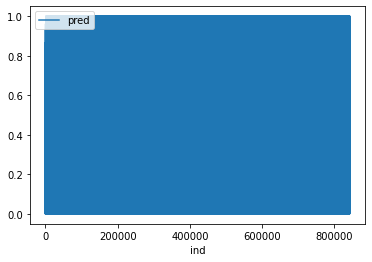

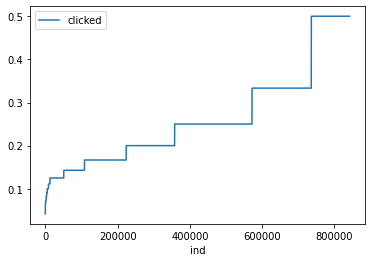

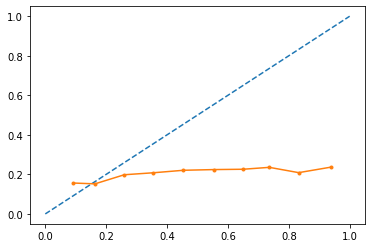

In [15]:
import joblib
filename = project_dir + 'svc_sigmoid.pkl'

svc = joblib.load(filename)

prob_svc_train = svc.predict_proba(train)
predict_svc_train = svc.predict(train)
score(y_train, predict_svc_train, prob_svc_train)
plot(predict_svc_train)
reliability_diagram(prob_svc_train[:, 1])

با توجه به دقت های بدست آمده کرنل گوسی بهترین عملکرد را داشت.

In [16]:
import joblib
filename = project_dir + 'svc_rbf.pkl'
svc = joblib.load(filename)

pred_random_svc = svc.predict(test)
prob_random_svc = svc.predict_proba(test)

joblib.dump(pred_random_svc, project_dir+'svc_test_pred.pkl')
joblib.dump(prob_random_svc, project_dir+'svc_test_probs.pkl')

['/content/drive/MyDrive/ML_Project/svc_test_probs.pkl']